## **Churn Analysis**
**Churn analysis** is the process of figuring out why customers stop doing business with you.

For this, we look at 2 things:
1. Who: Identifying which customers left or will leave in future 
2. Why: Analyzing their behavior before they left.

In [112]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
# remove warnings
import warnings
warnings.filterwarnings("ignore")

## **1. Import Data**

In [113]:
# Connect to SQLite database
conn = sqlite3.connect('customer_churn.db')

# This SQL query will fetch table names from db in a pandas dataframe, where name column contain all table names
tables = pd.read_sql("""SELECT name FROM sqlite_master WHERE type='table';""", conn)
print(tables)

# Close connection
conn.close()

              name
0      db_customer
1  db_subscription
2       db_support


In [114]:
# Now we will create Data Frames
conn = sqlite3.connect('customer_churn.db')

names = tables['name']

dfCustomer = pd.read_sql(f"SELECT * FROM {names[0]}", conn)
dfSubscription = pd.read_sql(f"SELECT * FROM {names[1]}", conn)
dfSupport = pd.read_sql(f"SELECT * FROM {names[2]}", conn)

conn.close()

In [115]:
dfCustomer.head()

,customerid,name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,NaN,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,NaN,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,None


In [116]:
dfSubscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaN,NaN,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaN,NaN,6.99,210,34
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaN,NaN,22.99,1725,8
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88


In [117]:
dfSupport.head()

,customerid,complaint_date,escalations,csat_score,col_1,comment
0,0003-MKNFE,2024-08-28 00:00:00,N,60,None,service issue
1,0003-MKNFE,2024-08-28 00:00:00,Y,10,None,demaned refund
2,0013-EXCHZ,2024-01-20 00:00:00,Y,20,None,NaN
3,0013-MHZWF,2025-03-18 00:00:00,N,90,None,guidance to renew
4,0013-SMEOE,2024-11-01 00:00:00,N,30,None,NaN


In [118]:
# Print table names and column names
conn = sqlite3.connect('customer_churn.db')

# Table: 1
print(f"\nTable Name: {names[0]}")
print("Columns:")
print(dfCustomer.columns)

# Table: 2
print(f"\nTable Name: {names[1]}")
print("Columns:")
print(dfSubscription.columns)

# Table: 3
print(f"\nTable Name: {names[2]}")
print("Columns:")
print(dfSupport.columns)

# Close connection
conn.close()


Table Name: db_customer
Columns:
Index(['customerid', 'name', 'country', 'state', 'gender', 'dob', 'interests',
       'pincode'],
      dtype='str')

Table Name: db_subscription
Columns:
Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score'],
      dtype='str')

Table Name: db_support
Columns:
Index(['customerid', 'complaint_date', 'escalations', 'csat_score', 'col_1',
       'comment'],
      dtype='str')


## **2. Data cleaning**

In [119]:
dfCustomer.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerid  21 non-null     str   
 1   name        21 non-null     str   
 2   country     18 non-null     str   
 3   state       21 non-null     str   
 4   gender      21 non-null     str   
 5   dob         21 non-null     str   
 6   interests   4 non-null      str   
 7   pincode     0 non-null      object
dtypes: object(1), str(7)
memory usage: 1.4+ KB


In [120]:
""" 
Steps we will do in Data Cleaning:
   a. rename col - name to customer_name
   b. drop columns - interest and pincode (becuase these are empty)
   c. change data type - dob
   d. data standardization - gender
   e. fix missing values (using existing data) - country
"""

' \nSteps we will do in Data Cleaning:\n   a. rename col - name to customer_name\n   b. drop columns - interest and pincode (becuase these are empty)\n   c. change data type - dob\n   d. data standardization - gender\n   e. fix missing values (using existing data) - country\n'

#### a. Rename Col

In [121]:
# a. rename col - name to customer_name

dfCustomer.rename(columns = {'name' : 'customer_name'}, inplace= True)

#### b. Drop columns

In [122]:
# b. drop columns - interest and pincode

# dfCustomer.drop(dfCustomer.columns[-2:], axis=1)
# dfCustomer.drop(dfCustomer.columns[6:], axis=1)

dfCustomer.drop(columns=['interests', 'pincode'], inplace=True)  # using col name

In [123]:
dfCustomer.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   customerid     21 non-null     str  
 1   customer_name  21 non-null     str  
 2   country        18 non-null     str  
 3   state          21 non-null     str  
 4   gender         21 non-null     str  
 5   dob            21 non-null     str  
dtypes: str(6)
memory usage: 1.1 KB


#### c. Change data type

In [124]:
# c. change data type - dob

dfCustomer['dob'] = pd.to_datetime(dfCustomer['dob'])

#### d. Data standardization

In [125]:
# d. data standardization - gender

# dfCustomer['gender'].unique()
dfCustomer['gender'].replace({'Men' : 'Male', 'Women' : 'Female'} , inplace=True)
dfCustomer['gender']

0       Male
1       Male
2     Female
3       Male
4     Female
5      Women
6     Female
7       Male
8      Women
9       Male
10       Men
11    Female
12    Female
13    Female
14       Men
15    Female
16    Female
17    Female
18      Male
19       Men
20     Women
Name: gender, dtype: str

In [126]:
dfCustomer['gender'].unique()

<StringArray>
['Male', 'Female', 'Women', 'Men']
Length: 4, dtype: str

#### e. Fix missing values

In [127]:
# e. fix missing values - country

dfCustomer['country'].isna().sum() # so there are 3 NULL values
dfCustomer[dfCustomer['country'].isna()]

,customerid,customer_name,country,state,gender,dob
5,0013-MHZWF,durga,NaN,Delhi,Women,1988-12-10
8,0015-UOCOJ,maya,NaN,Kathmandu,Women,1985-07-07
12,0018-NYROU,chitra,NaN,Telangana,Female,2004-12-01


In [128]:
# country and state - unique value pair

# Create: {"California":"USA", "Texas":"USA", "Punjab":"Pakistan"}
state_country_mapping = dfCustomer.dropna(subset=['country']).set_index('state')['country'].to_dict()

# Convert each state into its country
mapped = dfCustomer['state'].map(state_country_mapping)

# Fill only the missing countries
dfCustomer['country'] = dfCustomer['country'].fillna(mapped)

In [129]:
dfCustomer[dfCustomer['country'].isna()] # no null value in country col

,customerid,customer_name,country,state,gender,dob


In [130]:
dfSubscription.head() # subcription table

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaN,NaN,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaN,NaN,6.99,210,34
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaN,NaN,22.99,1725,8
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88


In [131]:
dfSubscription.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customerid               21 non-null     str    
 1   subscription_start_date  21 non-null     str    
 2   subscription_type        21 non-null     str    
 3   renewal_date             21 non-null     str    
 4   plan_type                21 non-null     str    
 5   contract_type            21 non-null     str    
 6   cancellation_date        6 non-null      str    
 7   cancellation_reason      6 non-null      str    
 8   monthly_charges          21 non-null     float64
 9   cltv                     21 non-null     int64  
 10  churn_score              21 non-null     int64  
dtypes: float64(1), int64(2), str(8)
memory usage: 1.9 KB


In [132]:
# change data type to date - subscription_start_date , renewal_date, cancellation_date
date_col = ['subscription_start_date', 'renewal_date', 'cancellation_date']

dfSubscription[date_col] = dfSubscription[date_col].apply(pd.to_datetime)
dfSubscription.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customerid               21 non-null     str           
 1   subscription_start_date  21 non-null     datetime64[us]
 2   subscription_type        21 non-null     str           
 3   renewal_date             21 non-null     datetime64[us]
 4   plan_type                21 non-null     str           
 5   contract_type            21 non-null     str           
 6   cancellation_date        6 non-null      datetime64[us]
 7   cancellation_reason      6 non-null      str           
 8   monthly_charges          21 non-null     float64       
 9   cltv                     21 non-null     int64         
 10  churn_score              21 non-null     int64         
dtypes: datetime64[us](3), float64(1), int64(2), str(5)
memory usage: 1.9 KB


In [133]:
dfSupport.head() # support table

,customerid,complaint_date,escalations,csat_score,col_1,comment
0,0003-MKNFE,2024-08-28 00:00:00,N,60,None,service issue
1,0003-MKNFE,2024-08-28 00:00:00,Y,10,None,demaned refund
2,0013-EXCHZ,2024-01-20 00:00:00,Y,20,None,NaN
3,0013-MHZWF,2025-03-18 00:00:00,N,90,None,guidance to renew
4,0013-SMEOE,2024-11-01 00:00:00,N,30,None,NaN


In [134]:
dfSupport.info()

<class 'pandas.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customerid      9 non-null      str   
 1   complaint_date  9 non-null      str   
 2   escalations     9 non-null      str   
 3   csat_score      9 non-null      int64 
 4   col_1           0 non-null      object
 5   comment         4 non-null      str   
dtypes: int64(1), object(1), str(4)
memory usage: 564.0+ bytes


In [135]:
# drop columns
dfSupport.drop(columns=['col_1', 'comment'], inplace=True)

In [136]:
# change data type to date - complaint_date

dfSupport['complaint_date'] = pd.to_datetime(dfSupport['complaint_date'])
dfSupport.info()

<class 'pandas.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   customerid      9 non-null      str           
 1   complaint_date  9 non-null      datetime64[us]
 2   escalations     9 non-null      str           
 3   csat_score      9 non-null      int64         
dtypes: datetime64[us](1), int64(1), str(2)
memory usage: 420.0 bytes


## **3. Feature Engineering & Data Analysis**

#### Create a new col

In [137]:
dfSubscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,NaN,6.99,210,34
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,NaN,22.99,1725,8
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88


In [138]:
# create a new col using existing col - churn flag | it will show if customer has left or not

# Customer is churned (or has left) if cancellation_date is not null
dfSubscription['churn_flag'] = np.where(dfSubscription['cancellation_date'].notna() , 1, 0)
dfSubscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,12,0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,NaN,6.99,210,34,0
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,NaN,22.99,1725,8,0
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88,1


#### Merge Dataframes - JOINs

In [139]:
# first fix support table duplicates then merge
# Note: while merging df's always check the shape before and after
df = (dfSubscription
            .merge(dfCustomer, on = 'customerid', how= 'left')
            .merge(dfSupport, on = 'customerid', how= 'left') )

In [140]:
df.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag,customer_name,country,state,gender,dob,complaint_date,escalations,csat_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,12,0,keshav,India,Maharashtra,Male,1982-04-12,NaT,NaN,NaN
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,N,60.0
2,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,Y,10.0
3,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,NaN,6.99,210,34,0,lalita,India,Delhi,Female,1978-02-15,NaT,NaN,NaN
4,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,NaN,22.99,1725,8,0,mohan,India,Nagaland,Male,2001-08-30,NaT,NaN,NaN


In [141]:
dfSubscription.shape

(21, 12)

In [142]:
df.shape

(23, 20)

In [143]:
print('dfSubscription unique value:', dfSubscription['customerid'].nunique())
print('dfCustomer unique value:', dfCustomer['customerid'].nunique())
print('dfSupport unique value:', dfSupport['customerid'].nunique())
print('dfSupport all value:', dfSupport['customerid'].size)

dfSubscription unique value: 21
dfCustomer unique value: 21
dfSupport unique value: 7
dfSupport all value: 9


In [144]:
dfSupport

,customerid,complaint_date,escalations,csat_score
0,0003-MKNFE,2024-08-28,N,60
1,0003-MKNFE,2024-08-28,Y,10
2,0013-EXCHZ,2024-01-20,Y,20
3,0013-MHZWF,2025-03-18,N,90
4,0013-SMEOE,2024-11-01,N,30
5,0017-IUDMW,2024-04-10,Y,25
6,0019-EFAEP,2024-09-27,Y,30
7,0022-TCJCI,2024-09-13,Y,10
8,0022-TCJCI,2024-09-14,N,90


In [145]:
dfSupport['complaint_count'] = dfSupport.groupby('customerid')['customerid'].transform('count')

In [146]:
dfSupport = dfSupport.sort_values('complaint_date').drop_duplicates('customerid', keep= 'last')

In [147]:
dfSupport['customerid'].size

7

In [148]:
# merge df
df = (dfSubscription
            .merge(dfCustomer, on = 'customerid', how= 'left')
            .merge(dfSupport, on = 'customerid', how= 'left') )

In [149]:
df.shape

(21, 21)

#### Export dataframe

In [150]:
# export dataframe to csv file
df.to_csv('exported_churn_data.csv', index=False)

## Data Analysis

In [151]:
# 1. Churn Rate
churn_rate = df['churn_flag'].mean()*100
print("Churn Rate = ", round(churn_rate,2), "%")

Churn Rate =  28.57 %


In [152]:
# 2. Retenion Rate = opposite of churn rate
retention_rate = 100 - churn_rate
print("Retention Rate = ", round(retention_rate,2), "%")

Retention Rate =  71.43 %


In [153]:
# 3. Churn by Plan type -> to check which plan type user are leaving more
churn_by_plan = (df.groupby('plan_type')['churn_flag'].mean().mul(100).round(2).reset_index(name='churn_rate_pct'))
print(churn_by_plan)

  plan_type  churn_rate_pct
0     Basic           60.00
1   Premium           14.29
2  Standard           22.22


In [154]:
# 4. ARPU - Avg Revenue per user
arpu = df['monthly_charges'].mean()
print('ARPU = ', round(arpu,2))

ARPU =  18.85


## 4. Visualization using Matplotlib

In [155]:
# best practice to create a copy then work on it
df_visual = df.copy()

In [156]:
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count'],
      dtype='str')

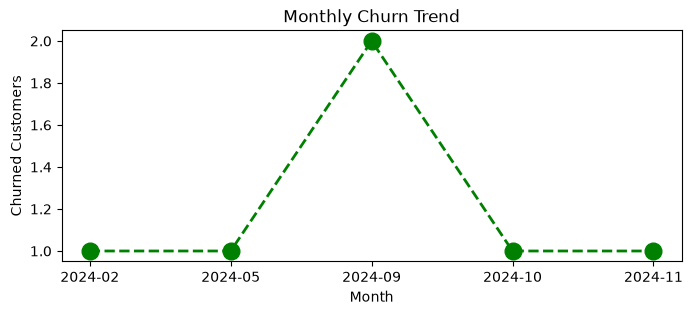

In [157]:
# 4.1 Monthly Churn Trend (Time Series KPI)

df_visual['cancellation_month'] = df_visual['cancellation_date'].dt.to_period('M')

churn_trend = df_visual[df_visual['churn_flag'] == 1].groupby('cancellation_month').size()

plt.figure(figsize=(8,3))
plt.plot(churn_trend.index.astype(str), churn_trend.values,  color='green', marker='o', linestyle='dashed',  linewidth=2, markersize=12)

plt.title('Monthly Churn Trend')
plt.xlabel('Month')
plt.ylabel('Churned Customers')
plt.show()

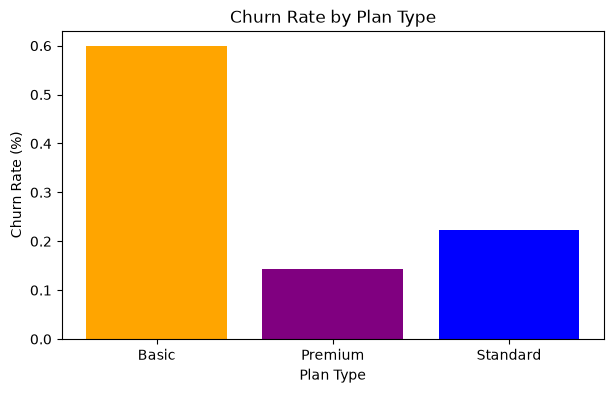

In [158]:
# 4.2 Churn Rate by Plan type
churn_plan = df_visual.groupby('plan_type')['churn_flag'].mean()

colors = ['orange', 'purple', 'blue']

plt.figure(figsize=(7,4))
plt.bar(churn_plan.index, churn_plan.values, color = colors)

plt.title('Churn Rate by Plan Type')
plt.xlabel('Plan Type')
plt.ylabel('Churn Rate (%)')
plt.show()

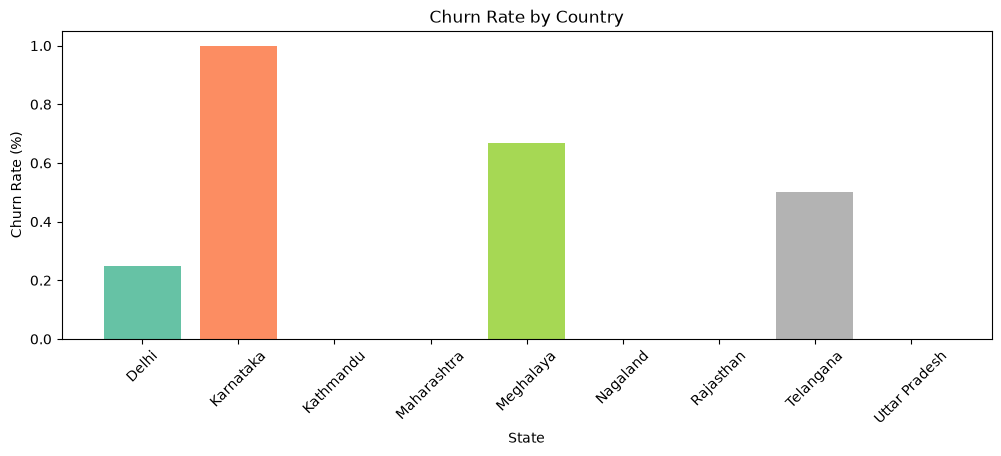

In [159]:
# 4.3 Churn by States [same as above but for state groupby]
churn_plan = df_visual.groupby('state')['churn_flag'].mean()

# colors = ['yellow', 'purple', 'blue']
colors = plt.cm.Set2(np.linspace(0, 1, len(churn_plan)))

plt.figure(figsize=(12,4))
plt.bar(churn_plan.index, churn_plan.values, color = colors)

plt.title('Churn Rate by Country')
plt.xlabel('State')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=45)
plt.show()

## Pivot table

In [160]:
# Pivot Table

pd.pivot_table(
    df_visual,
    index='plan_type',
    values='churn_flag',
    aggfunc = 'mean'
)

,churn_flag
plan_type,
Basic,0.600000
Premium,0.142857
Standard,0.222222


In [161]:
# pivot table using multiple cols and agg type

pd.pivot_table(
    df_visual,
    index='plan_type',
    values=['monthly_charges', 'customerid', 'churn_flag'],
    aggfunc = {
        'monthly_charges' : 'sum',
        'customerid' : 'nunique',
        'churn_flag' : 'mean'
    }
)

,churn_flag,customerid,monthly_charges
plan_type,,,
Basic,0.600000,5,52.95
Premium,0.142857,7,218.93
Standard,0.222222,9,123.91
